**Visualizacion de los datos**


In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt

archivo = 'Bike_Sales_Outlier_Lab.xlsx'
if not os.path.exists(archivo):
    from google.colab import files
    files.upload()

data = pd.read_excel(archivo)
data.columns = data.columns.str.strip()
print(data.shape)
print(data.columns)

(88, 19)
Index(['Sales_Order #', 'Date', 'Day', 'Month', 'Year', 'Customer_Age',
       'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product_Description', 'Order_Quantity', 'Unit_Cost',
       'Unit_Price', 'Profit', 'Cost', 'Revenue'],
      dtype='object')


**Tabla dinamica**

In [16]:
pivot = data.groupby('Date')['Order_Quantity'].sum().reset_index()
pivot.columns = ['Fecha', 'Suma_Order_Quantity']
pivot

,Fecha,Suma_Order_Quantity
0,2021-12-01,5
1,2021-12-02,3
2,2021-12-03,4
3,2021-12-04,4
4,2021-12-05,10
5,2021-12-06,6
6,2021-12-07,6
7,2021-12-08,11
8,2021-12-09,3
9,2021-12-10,8


**Ordenar de mayor a menor**

In [17]:
pivot_ord = pivot.sort_values('Suma_Order_Quantity', ascending=False)
pivot_ord

,Fecha,Suma_Order_Quantity
18,2021-12-19,43
17,2021-12-18,19
19,2021-12-20,13
11,2021-12-12,12
7,2021-12-08,11
4,2021-12-05,10
21,2021-12-22,10
9,2021-12-10,8
10,2021-12-11,8
6,2021-12-07,6


En que fecha se registro la mayor cantidad de ventas? 19/12/2021.  
Cuál fue la cantidad? 43 unidades.

In [18]:
dia = data[data['Date'] == '2021-12-19']
print(dia[['Sales_Order #', 'Order_Quantity', 'Revenue']])
dia.loc[dia['Order_Quantity'].idxmax()]

    Sales_Order #  Order_Quantity  Revenue
61         261756               4     9280
62         261757               4     2160
63         261758               4     9180
64         261759               4    13500
65         261760               4     9180
66         261761               4     9180
67         261762               4     9180
68         261763               2     1080
69         261764               2     4590
70         261765              11    25520


,70
Sales_Order #,261765
Date,2021-12-19 00:00:00
Day,19
Month,December
Year,2021
Customer_Age,39
Age_Group,Adults (35-64)
Customer_Gender,F
Country,United States
State,Washington


Que entrada contribuye mas? El pedido Sales_Order # 261765, con 11 unidades. Los demas pedidos de ese dia tienen 4 unidades o menos.

**Grafico de dispersion**

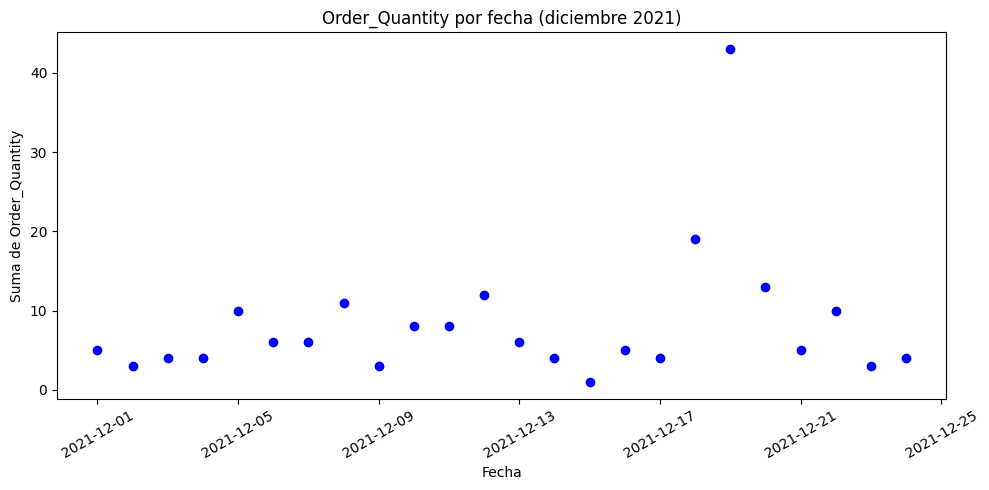

In [19]:
plt.figure(figsize=(10, 5))
plt.scatter(pivot['Fecha'], pivot['Suma_Order_Quantity'], color='b')
plt.title('Order_Quantity por fecha (diciembre 2021)')
plt.xlabel('Fecha')
plt.ylabel('Suma de Order_Quantity')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Equivalente de grande y pequeño**

In [20]:
s = pivot['Suma_Order_Quantity']
print('Mayor valor (grande 1):', s.max())
print('5 mas altos:', s.nlargest(5).tolist())
print('6 mas bajos (pequeño):', s.nsmallest(6).tolist())

q1, q3 = s.quantile(0.25), s.quantile(0.75)
iqr = q3 - q1
limite = q3 + 1.5 * iqr
print('Q1 =', q1, '| Q3 =', q3, '| IQR =', iqr, '| limite superior =', limite)
print('Atipicos:', pivot[s > limite].to_dict('records'))

Mayor valor (GRANDE 1): 43
5 más altos: [43, 19, 13, 12, 11]
6 más bajos (PEQUEÑO): [1, 3, 3, 3, 4, 4]
Q1 = 4.0 | Q3 = 10.0 | IQR = 6.0 | límite superior = 19.0
Atípicos: [{'Fecha': Timestamp('2021-12-19 00:00:00'), 'Suma_Order_Quantity': 43}]


En Excel: =GRANDE($E$4:$E$27;1), =GRANDE($E$4:$E$27;FILA($1:$5)) y =PEQUEÑO($E$4:$E$27;FILA($1:$6)).

**Cantidad de ordenes vs ingresos**

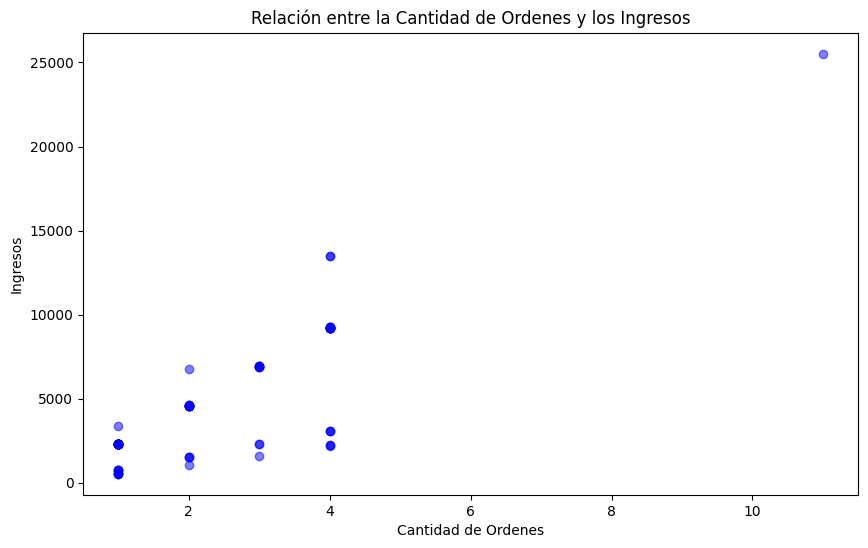

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(data['Order_Quantity'], data['Revenue'], color='b', alpha=0.5)
plt.title('Relacion entre la Cantidad de Ordenes y los Ingresos')
plt.xlabel('Cantidad de Ordenes')
plt.ylabel('Ingresos')
plt.show()

**Interpretación:** a mayor cantidad por orden los ingresos tienden a aumentar, pero con mucha variabilidad, porque dependen del modelo de bicicleta. El punto aislado (11 unidades, 25.520 de ingresos) es el pedido 261765, atípico en cantidad e ingresos. Además, su `Profit` (1.054) no coincide con 11 × (2.320 − 1.266) = 11.594, lo que sugiere un error de digitación.

**Ejercicio 2**

Calificaciones por asignatura

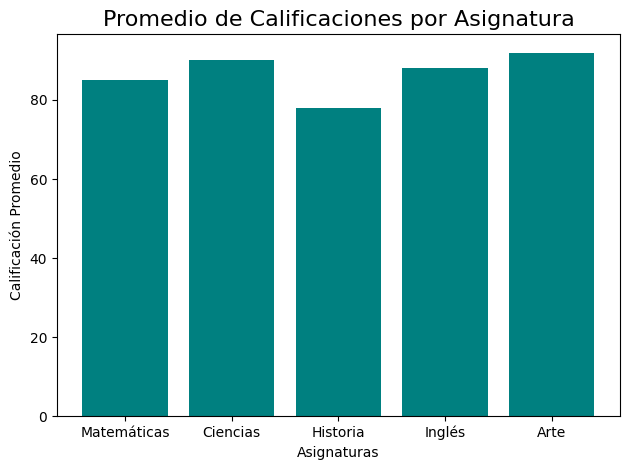

In [22]:
asignaturas = ['Matemáticas', 'Ciencias', 'Historia', 'Inglés', 'Arte']
calificaciones = [85, 90, 78, 88, 92]

plt.bar(asignaturas, calificaciones, color='teal')
plt.title('Promedio de Calificaciones por Asignatura', fontsize=16)
plt.xlabel('Asignaturas')
plt.ylabel('Calificación Promedio')
plt.tight_layout()
plt.show()

Interpretacion: Arte (92) y Ciencias (90) tienen los mejores resultados; Historia (78) tiene el promedio más bajo.

Tiempo de carga de sitios web

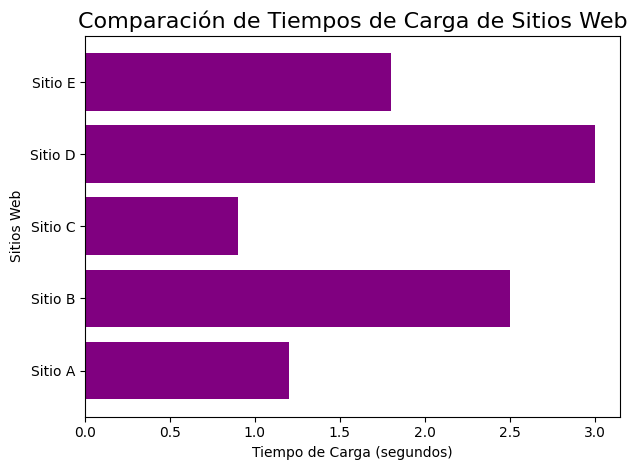

In [23]:
sitios = ['Sitio A', 'Sitio B', 'Sitio C', 'Sitio D', 'Sitio E']
tiempos = [1.2, 2.5, 0.9, 3.0, 1.8]

plt.barh(sitios, tiempos, color='purple')
plt.title('Comparación de Tiempos de Carga de Sitios Web', fontsize=16)
plt.xlabel('Tiempo de Carga (segundos)')
plt.ylabel('Sitios Web')
plt.tight_layout()
plt.show()

Interpretacion: el Sitio C es el más rápido (0,9 s) y el Sitio D el más lento (3,0 s).

Horas de estudio vs. rendimiento

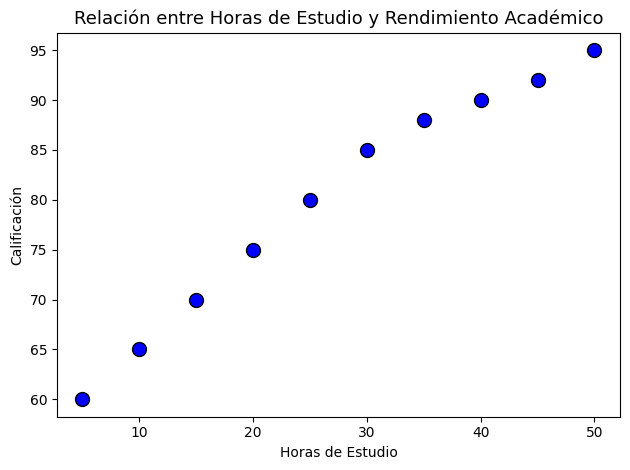

Correlación de Pearson: 0.99


In [24]:
horas_estudio = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
calificaciones = [60, 65, 70, 75, 80, 85, 88, 90, 92, 95]

plt.scatter(horas_estudio, calificaciones, color='blue', s=100, edgecolor='black')
plt.title('Relación entre Horas de Estudio y Rendimiento Académico', fontsize=13)
plt.xlabel('Horas de Estudio')
plt.ylabel('Calificación')
plt.tight_layout()
plt.show()

import numpy as np
print('Correlación de Pearson:', round(np.corrcoef(horas_estudio, calificaciones)[0, 1], 2))

Interpretacion: correlación positiva fuerte (r ≈ 0,99): a más horas de estudio, mayor calificación. Correlación no implica causalidad.

Distribución de salarios por departamento

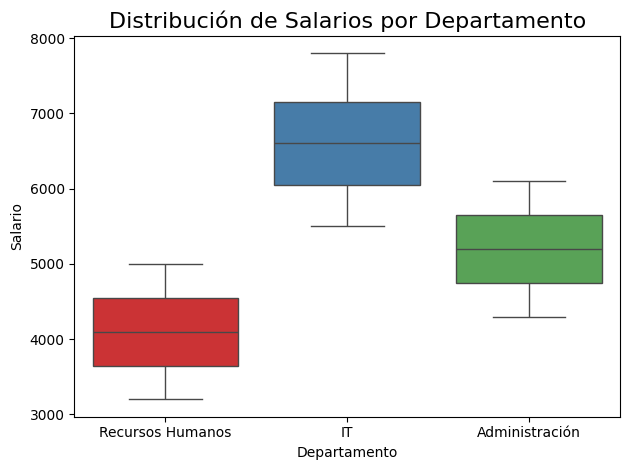

In [25]:
import seaborn as sns

datos_salarios = {
    'Departamento': ['Recursos Humanos']*10 + ['IT']*10 + ['Administración']*10,
    'Salario': [3200, 3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800, 5000,
                5500, 5700, 6000, 6200, 6500, 6700, 7000, 7200, 7500, 7800,
                4300, 4500, 4700, 4900, 5100, 5300, 5500, 5700, 5900, 6100]
}
df_salarios = pd.DataFrame(datos_salarios)

sns.boxplot(x='Departamento', y='Salario', data=df_salarios,
            hue='Departamento', palette='Set1', legend=False)
plt.title('Distribución de Salarios por Departamento', fontsize=16)
plt.xlabel('Departamento')
plt.ylabel('Salario')
plt.tight_layout()
plt.show()

nterpretacion: IT tiene la mayor mediana (6.600) y la mayor dispersión. Recursos Humanos (mediana 4.100) y Administración (5.200) tienen la menor variabilidad, con el mismo rango (1.800). No hay valores atípicos.